In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, accuracy_score, roc_auc_score
)
from itertools import product
import warnings
warnings.filterwarnings('ignore')

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_PATH = "."
DATASET_PATH = f"{BASE_PATH}/dataset_m/promoter_final_dataset.csv"
OUT_CSV = f"{BASE_PATH}/baseline_results.csv"

KMER_K = 3
NN_EPOCHS = 15
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")

Device: cuda


In [ ]:
df = pd.read_csv(DATASET_PATH)
sd = {n: df[df['split'] == n].reset_index(drop=True)
      for n in ['train', 'val', 'id_test', 'ood_test']}
print("\nSplit sizes:")
for n, s in sd.items():
    print(f"  {n}: {len(s)} ({s['label'].mean()*100:.1f}% promoters)")


Split sizes:
  train: 7623 (17.3% promoters)
  val: 1634 (17.3% promoters)
  id_test: 1634 (17.3% promoters)
  ood_test: 8137 (17.3% promoters)


In [ ]:
SEQ_LEN = len(df.iloc[0]['sequence'])
print(f"Sequence length: {SEQ_LEN} bp")

# Class weights from training split (same as DNABERT script)
y_train = sd['train']['label'].values
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
cw_t = torch.tensor(cw, dtype=torch.float).to(device)
print(f"Class weights: {cw.tolist()}")

Sequence length: 300 bp
Class weights: [0.6044243577545195, 2.8940774487471526]


In [ ]:
results = []
def record(model_name, split_label, y_true, y_pred, y_prob=None):
    """Append one result row and print it."""
    row = {
        'Model': model_name,
        'Split': split_label,
        'f1': f1_score(y_true, y_pred, average='binary'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
    }
    results.append(row)
    print(f"  {model_name:<16} {split_label:<10} "
          f"F1={row['f1']:.4f}  BalAcc={row['balanced_accuracy']:.4f}  "
          f"AUC={row['roc_auc']:.4f}" if y_prob is not None
          else f"  {model_name:<16} {split_label:<10} "
               f"F1={row['f1']:.4f}  BalAcc={row['balanced_accuracy']:.4f}")
    return row

In [ ]:
print(f"[1] k-mer (k={KMER_K}) frequency + KNN:")

kmer_vocab = [''.join(p) for p in product('ACGT', repeat=KMER_K)]
kmer_idx = {k: i for i, k in enumerate(kmer_vocab)}

def kmer_features(seqs, k=KMER_K):
    X = np.zeros((len(seqs), len(kmer_vocab)), dtype=np.float32)
    for r, seq in enumerate(seqs):
        seq = seq.upper()
        total = 0
        for i in range(len(seq) - k + 1):
            km = seq[i:i + k]
            if km in kmer_idx:
                X[r, kmer_idx[km]] += 1
                total += 1
        if total > 0:
            X[r] /= total
    return X

X_tr = kmer_features(sd['train']['sequence'].tolist())
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)

knn = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn.fit(X_tr, y_train)

for split_key, split_label in [('id_test', 'ID Test'), ('ood_test', 'OOD Test')]:
    Xs = scaler.transform(kmer_features(sd[split_key]['sequence'].tolist()))
    ys = sd[split_key]['label'].values
    pred = knn.predict(Xs)
    prob = knn.predict_proba(Xs)[:, 1]
    record(f'k-mer+KNN (k={KMER_K})', split_label, ys, pred, prob)

BASES = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

def one_hot(seqs, length=SEQ_LEN):
    X = np.zeros((len(seqs), length, 4), dtype=np.float32)
    for r, seq in enumerate(seqs):
        for i, b in enumerate(seq.upper()[:length]):
            if b in BASES:
                X[r, i, BASES[b]] = 1.0
    return X

def make_loader(split_key, batch=64, shuffle=False):
    X = one_hot(sd[split_key]['sequence'].tolist())
    y = sd[split_key]['label'].values
    X = torch.tensor(X).permute(0, 2, 1)
    y = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch, shuffle=shuffle)

train_loader = make_loader('train', shuffle=True)
loaders = {k: make_loader(k) for k in ['val', 'id_test', 'ood_test']}

def train_nn(model, name):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.CrossEntropyLoss(weight=cw_t)
    best_val, best_state = -1, None
    for epoch in range(NN_EPOCHS):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward()
            opt.step()
        # validation macro F1 for model selection
        vy, vp, _ = predict_nn(model, loaders['val'])
        vf1 = f1_score(vy, vp, average='macro')
        if vf1 > best_val:
            best_val, best_state = vf1, {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    print(f"  {name}: best val macro F1 = {best_val:.4f}")
    return model

def predict_nn(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            logits = model(Xb)
            prob = torch.softmax(logits, dim=1)[:, 1]
            ps.extend(logits.argmax(1).cpu().numpy())
            probs.extend(prob.cpu().numpy())
            ys.extend(yb.numpy())
    return np.array(ys), np.array(ps), np.array(probs)

[1] k-mer (k=3) frequency + KNN:
  k-mer+KNN (k=3)  ID Test    F1=0.1615  BalAcc=0.5409  AUC=0.7305
  k-mer+KNN (k=3)  OOD Test   F1=0.5781  BalAcc=0.7400  AUC=0.8345


In [ ]:
print("[2] CNN:")

class CNN(nn.Module):
    def __init__(self, seq_len=SEQ_LEN):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=11, padding=5), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=7, padding=3), nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.head(self.conv(x))

cnn = train_nn(CNN(), 'CNN')
for split_key, split_label in [('id_test', 'ID Test'), ('ood_test', 'OOD Test')]:
    y, p, pr = predict_nn(cnn, loaders[split_key])
    record('CNN', split_label, y, p, pr)

[2] CNN:
  CNN: best val macro F1 = 0.6781
  CNN              ID Test    F1=0.4682  BalAcc=0.6685  AUC=0.7996
  CNN              OOD Test   F1=0.4925  BalAcc=0.7620  AUC=0.8660


In [ ]:
print("[3] BiLSTM:")

class BiLSTM(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.lstm = nn.LSTM(4, hidden, num_layers=1, batch_first=True,
                            bidirectional=True)
        self.head = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        pooled = out.mean(dim=1)
        return self.head(pooled)

bilstm = train_nn(BiLSTM(), 'BiLSTM')
for split_key, split_label in [('id_test', 'ID Test'), ('ood_test', 'OOD Test')]:
    y, p, pr = predict_nn(bilstm, loaders[split_key])
    record('BiLSTM', split_label, y, p, pr)

[3] BiLSTM:
  BiLSTM: best val macro F1 = 0.6060
  BiLSTM           ID Test    F1=0.4068  BalAcc=0.6507  AUC=0.6952
  BiLSTM           OOD Test   F1=0.3530  BalAcc=0.6166  AUC=0.8036


In [ ]:
out = pd.DataFrame(results)
out.to_csv(OUT_CSV, index=False)
print(out.to_string(index=False))
print(f"\nSaved: {OUT_CSV}")

          Model    Split       f1  balanced_accuracy  accuracy  roc_auc
k-mer+KNN (k=3)  ID Test 0.161491           0.540922  0.834761 0.730462
k-mer+KNN (k=3) OOD Test 0.578073           0.739952  0.859531 0.834453
            CNN  ID Test 0.468172           0.668474  0.841493 0.799556
            CNN OOD Test 0.492474           0.762041  0.689197 0.865975
         BiLSTM  ID Test 0.406828           0.650735  0.744798 0.695209
         BiLSTM OOD Test 0.352989           0.616606  0.408013 0.803570

Saved: ./baseline_results.csv


In [ ]:
# Ablation Study
import numpy as np
import pandas as pd
import random
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, balanced_accuracy_score, accuracy_score, roc_auc_score)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def extract_kmers(seq, k=6):
    return {seq[i:i+k] for i in range(len(seq)-k+1)}

def build_balanced_motif_ood_splits(df, k=6, num_heldout_motifs=50, train_frac=0.6, val_frac=0.1, id_test_frac=0.1, random_state=42):
    df = df.copy().reset_index(drop=True)
    rng = np.random.RandomState(random_state)
    all_motifs = set().union(*df['sequence'].apply(lambda s: extract_kmers(s, k)))
    all_motifs = list(all_motifs)
    rng.shuffle(all_motifs)

    num_heldout_motifs = min(num_heldout_motifs, len(all_motifs))
    heldout = set(all_motifs[:num_heldout_motifs])

    def is_ood(seq):
        return len(extract_kmers(seq, k) & heldout) > 0

    df['is_ood'] = df['sequence'].apply(is_ood)
    id_df = df[df['is_ood'] == False].copy()
    ood_df = df[df['is_ood'] == True].copy()
    id_train_val, id_test = train_test_split(id_df, test_size=id_test_frac, stratify=id_df['label'], random_state=random_state)

    rel_val = val_frac / (train_frac + val_frac)
    id_train, id_val = train_test_split(id_train_val, test_size=rel_val, stratify=id_train_val['label'], random_state=random_state)

    ood_pos = ood_df[ood_df['label'] == 1]
    ood_neg = ood_df[ood_df['label'] == 0]

    if len(ood_pos) == 0 or len(ood_neg) == 0:
        ood_bal = ood_df
    else:
        n_min = min(len(ood_pos), len(ood_neg))
        ood_bal = pd.concat([ood_pos.sample(n=n_min, random_state=random_state), ood_neg.sample(n=n_min, random_state=random_state)]).sample(frac=1.0, random_state=random_state)

    return id_train, id_val, id_test, ood_bal, heldout

full_df = df.copy()

id_train, id_val, id_test, ood_test, heldout_motifs = build_balanced_motif_ood_splits(full_df, k=6, num_heldout_motifs=50, train_frac=0.6, val_frac=0.1, id_test_frac=0.1, random_state=42)

sd = {'train': id_train.reset_index(drop=True), 'val': id_val.reset_index(drop=True), 'id_test': id_test.reset_index(drop=True), 'ood_test': ood_test.reset_index(drop=True)}

print("Split sizes (after balanced motif OOD):")

for k in ['train', 'val', 'id_test', 'ood_test']:
    frac_pos = sd[k]['label'].mean()
    print(f"  {k}: {len(sd[k])} ({frac_pos*100:.1f}% positives)")

SEQ_LEN = len(sd['train']['sequence'].iloc[0])

pos_frac = sd['train']['label'].mean()
neg_frac = 1.0 - pos_frac
cw = [1.0 / neg_frac, 1.0 / pos_frac]
cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
print("Class weights:", cw)

results = []

def record(model_name, split_label, y_true, y_pred, y_prob=None):
    row = {
        'Model': model_name,'Split': split_label, 'f1': f1_score(y_true, y_pred, average='binary'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),'accuracy': accuracy_score(y_true, y_pred), 'roc_auc': roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,}

    results.append(row)
    print(f"  {model_name:<20} {split_label:<10} " f"F1={row['f1']:.4f}  BalAcc={row['balanced_accuracy']:.4f}  " f"AUC={row['roc_auc']:.4f}")
    return row


KMER_K = 3
kmer_vocab = [''.join(p) for p in product('ACGT', repeat=KMER_K)]
kmer_idx = {k: i for i, k in enumerate(kmer_vocab)}

def kmer_features(seqs, k=KMER_K):
    X = np.zeros((len(seqs), len(kmer_vocab)), dtype=np.float32)
    for r, seq in enumerate(seqs):
        seq = seq.upper()
        total = 0
        for i in range(len(seq) - k + 1):
            km = seq[i:i+k]
            if km in kmer_idx:
                X[r, kmer_idx[km]] += 1
                total += 1
        if total > 0:
            X[r] /= total
    return X

print("\n[1] k-mer (k=3) + KNN baseline")

X_tr = kmer_features(sd['train']['sequence'].tolist())
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
y_train = sd['train']['label'].values

knn = KNeighborsClassifier(n_neighbors=15, weights='distance')

knn.fit(X_tr, y_train)

for split_key, split_label in [('id_test', 'ID Test'), ('ood_test', 'OOD Test')]:
    Xs = scaler.transform(kmer_features(sd[split_key]['sequence'].tolist()))
    ys = sd[split_key]['label'].values
    pred = knn.predict(Xs)
    prob = knn.predict_proba(Xs)[:, 1]
    record(f'k-mer+KNN (k={KMER_K})', split_label, ys, pred, prob)

BASES = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

def one_hot(seqs, length=SEQ_LEN):
    X = np.zeros((len(seqs), length, 4), dtype=np.float32)
    for r, seq in enumerate(seqs):
        for i, b in enumerate(seq.upper()[:length]):
            if b in BASES:
                X[r, i, BASES[b]] = 1.0
    return X

def make_loader(split_key, batch=64, shuffle=False):
    X = one_hot(sd[split_key]['sequence'].tolist())
    y = sd[split_key]['label'].values
    X = torch.tensor(X).permute(0, 2, 1)
    y = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=batch, shuffle=shuffle)

train_loader = make_loader('train', shuffle=True)
loaders = {k: make_loader(k) for k in ['val', 'id_test', 'ood_test']}

NN_EPOCHS = 10

def predict_nn(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            logits = model(Xb)
            prob = torch.softmax(logits, dim=1)[:, 1]
            ps.extend(logits.argmax(1).cpu().numpy())
            probs.extend(prob.cpu().numpy())
            ys.extend(yb.numpy())
    return np.array(ys), np.array(ps), np.array(probs)

def train_nn(model, name):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.CrossEntropyLoss(weight=cw_t)
    best_val, best_state = -1, None

    for epoch in range(NN_EPOCHS):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward()
            opt.step()

        vy, vp, _ = predict_nn(model, loaders['val'])
        vf1 = f1_score(vy, vp, average='macro')

        if vf1 > best_val:
            best_val = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state:
        model.load_state_dict(best_state)

    print(f"  {name}: best val macro F1 = {best_val:.4f}")
    return model

print("\n[2] CNN baseline")

cnn = CNN()
cnn = train_nn(cnn, "CNN")

for split_key, split_label in [('id_test', 'ID Test'), ('ood_test', 'OOD Test')]:
    y, p, pr = predict_nn(cnn, loaders[split_key])
    record("CNN", split_label, y, p, pr)

print("\n[3] BiLSTM baseline")

bilstm = BiLSTM()
bilstm = train_nn(bilstm, "BiLSTM")

for split_key, split_label in [('id_test', 'ID Test'), ('ood_test', 'OOD Test')]:
    y, p, pr = predict_nn(bilstm, loaders[split_key])
    record("BiLSTM", split_label, y, p, pr)

out = pd.DataFrame(results)
print("\nFinal Results:")
print(out.to_string(index=False))


Split sizes (after balanced motif OOD):
  train: 726 (36.5% positives)
  val: 122 (36.9% positives)
  id_test: 95 (36.8% positives)
  ood_test: 16590 (50.0% positives)
Class weights: [np.float64(1.574837310195228), np.float64(2.739622641509434)]

[1] k-mer (k=3) + KNN baseline
  k-mer+KNN (k=3)      ID Test    F1=0.6182  BalAcc=0.7179  AUC=0.8419
  k-mer+KNN (k=3)      OOD Test   F1=0.6346  BalAcc=0.7164  AUC=0.8116

[2] CNN baseline
  CNN: best val macro F1 = 0.7108
  CNN                  ID Test    F1=0.6269  BalAcc=0.7083  AUC=0.8233
  CNN                  OOD Test   F1=0.7292  BalAcc=0.7497  AUC=0.8266

[3] BiLSTM baseline
  BiLSTM: best val macro F1 = 0.7342
  BiLSTM               ID Test    F1=0.5952  BalAcc=0.6571  AUC=0.7810
  BiLSTM               OOD Test   F1=0.7338  BalAcc=0.7329  AUC=0.8150

Final Results:
          Model    Split       f1  balanced_accuracy  accuracy  roc_auc
k-mer+KNN (k=3)  ID Test 0.618182           0.717857  0.778947 0.841905
k-mer+KNN (k=3) OOD Test 0


=== CONFUSION MATRICES ===


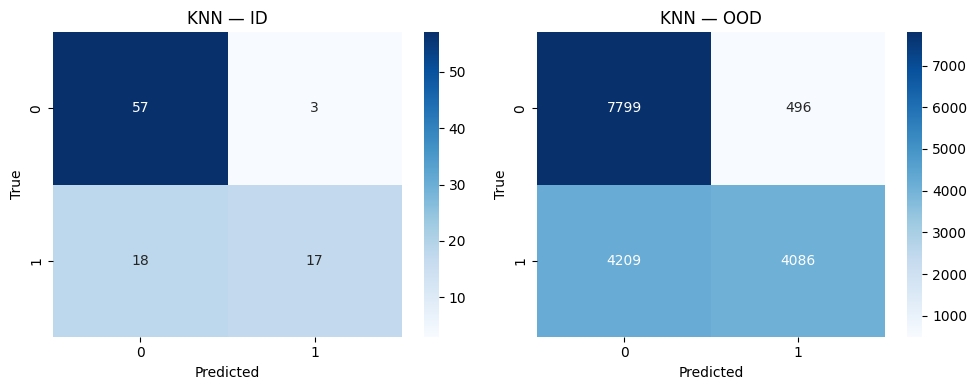

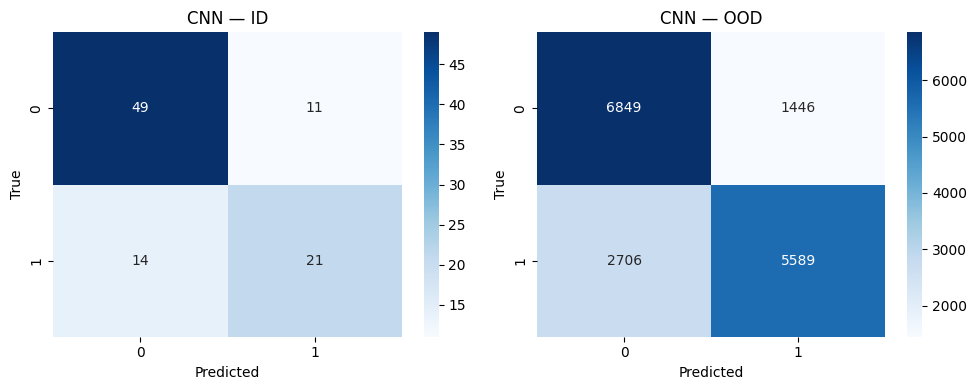

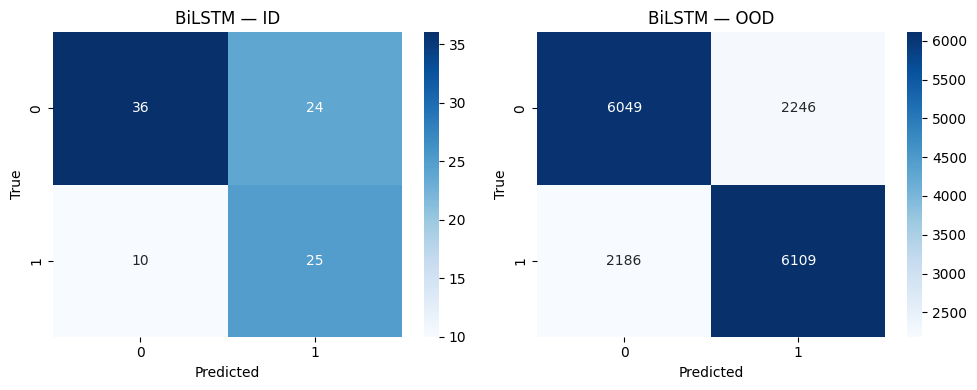


=== SALIENCY MAPS (CNN & BiLSTM) ===


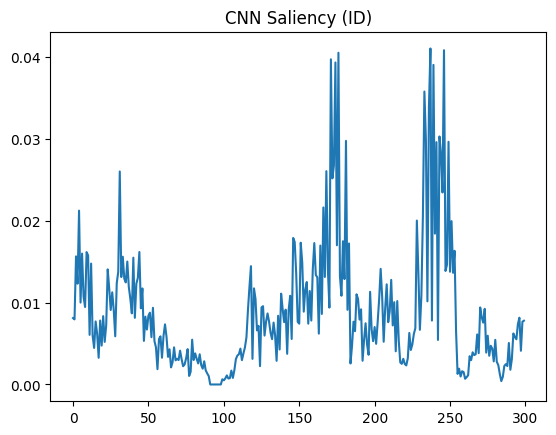

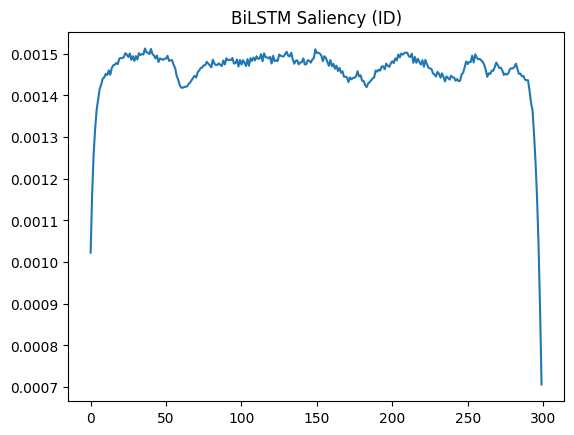


=== MOTIF ENRICHMENT (FP/FN) ===

KNN — Top FP motifs: [('AAAAAA', 534), ('GGGAGG', 341), ('GGCAGG', 252), ('GGAGGC', 242), ('CAGGAG', 239), ('AGGCAG', 234), ('AGGAGG', 222), ('GGAGGG', 220), ('AGGAGA', 202), ('GGTGGG', 202)]
KNN — Top FN motifs: [('TTTTTT', 4449), ('AAAAAA', 2633), ('TTTCTT', 1419), ('TTTTCT', 1407), ('TTCTTT', 1386), ('ATTTTT', 1275), ('CACACA', 1194), ('TTTAAA', 1179), ('TTTTAA', 1178), ('AGAAAA', 1155)]

CNN — Top FP motifs: [('AAAAAA', 1795), ('GGGAGG', 927), ('GGAGGC', 759), ('CAGGAG', 720), ('AGGCAG', 660), ('CCCAGC', 653), ('CCTGGG', 645), ('GGCAGG', 640), ('TCCCAG', 636), ('TGGGAG', 628)]
CNN — Top FN motifs: [('TTTTTT', 3564), ('AAAAAA', 2124), ('TTTCTT', 1113), ('TTTTCT', 1100), ('ATTTTT', 1088), ('TTCTTT', 1087), ('TTTAAA', 1053), ('TTTTAA', 1035), ('TTTTTA', 999), ('TATTTT', 998)]

BiLSTM — Top FP motifs: [('AAAAAA', 2030), ('TTTTTT', 1580), ('CAGCCT', 1111), ('AGGCTG', 1060), ('GGGAGG', 1013), ('CCTCCC', 992), ('CAGGAG', 966), ('CCCAGC', 954), ('TCCCAG',

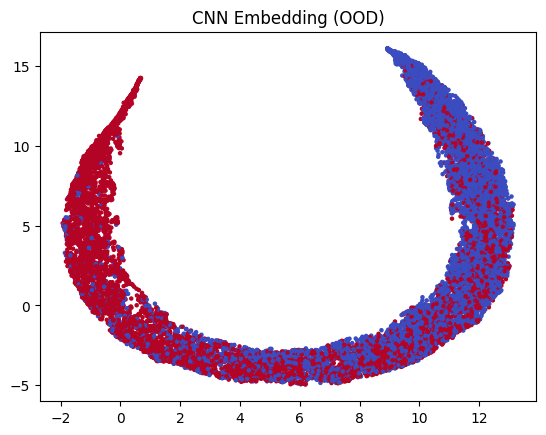

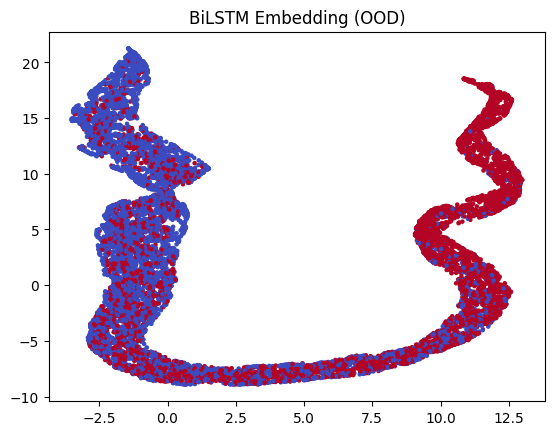


=== OOD DIFFICULTY SWEEP (CNN example) ===
  CNN-k5: best val macro F1 = 0.7074
  CNN-k10: best val macro F1 = 0.7151
  CNN-k20: best val macro F1 = 0.6968
  CNN-k40: best val macro F1 = 0.6998
  CNN-k80: best val macro F1 = 0.7025
k held-out motifs → OOD F1: [(5, 0.7411284146030125), (10, 0.7368421052631579), (20, 0.7272727272727273), (40, 0.64), (80, 0.6923076923076923)]


In [ ]:
# Evaluation

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

from sklearn.manifold import TSNE
import umap
HAS_UMAP = True

def get_predictions(model, loader, is_knn=False):
    if is_knn:
        seqs = []
        ys = []
        for xb, yb in loader:
            xb_np = xb.permute(0,2,1).numpy()
            for row in xb_np:
                seq = "".join("ACGT"[i] for i in row.argmax(axis=1))
                seqs.append(seq)
            ys.append(yb.numpy())

        ys = np.hstack(ys)
        X = kmer_features(seqs)
        X = scaler.transform(X)
        prob = model.predict_proba(X)[:, 1]
        pred = (prob >= 0.5).astype(int)
        return ys, pred, prob

    else:
        return predict_nn(model, loader)


def evaluate_model(name, model, loaders, is_knn=False):
    y, p, pr = get_predictions(model, loaders['id_test'], is_knn=is_knn)
    record(name, "ID Test", y, p, pr)

    y, p, pr = get_predictions(model, loaders['ood_test'], is_knn=is_knn)
    record(name, "OOD Test", y, p, pr)

def get_embeddings(model, xb):
    model.eval()
    activations = {}
    last_linear = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            last_linear = name

    if last_linear is None:
        raise ValueError("No Linear layer found in model — cannot extract embeddings.")

    def hook_fn(module, input, output):
        activations['emb'] = input[0].detach()

    layer = dict(model.named_modules())[last_linear]
    hook = layer.register_forward_hook(hook_fn)
    _ = model(xb)
    hook.remove()

    return activations['emb'].cpu().numpy()



def plot_confusion_matrices(models, loaders):
    for name, model in models.items():
        is_knn = ("KNN" in name)
        fig, axes = plt.subplots(1, 2, figsize=(10,4))
        for ax, split_key, split_label in [(axes[0], 'id_test', 'ID'), (axes[1], 'ood_test', 'OOD')]:
            y, p, _ = get_predictions(model, loaders[split_key], is_knn=is_knn)
            cm = confusion_matrix(y, p)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
            ax.set_title(f"{name} — {split_label}")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
        plt.tight_layout()
        plt.show()


def saliency_map(model, sequence_tensor):
    if hasattr(model, "lstm") or hasattr(model, "rnn"):
        model.train()
    else:
        model.eval()

    sequence_tensor = sequence_tensor.clone().detach().requires_grad_(True)
    out = model(sequence_tensor)
    out.backward(torch.ones_like(out))
    saliency = sequence_tensor.grad.abs().sum(dim=1).cpu().numpy()
    return saliency

def plot_saliency(model, loader, title):
    xb, yb = next(iter(loader))
    sal = saliency_map(model, xb[:1].to(device))
    plt.plot(sal[0])
    plt.title(title)
    plt.show()

from collections import Counter

def kmer_enrichment(seqs, k=6):
    kmers = []
    for s in seqs:
        for i in range(len(s)-k+1):
            kmers.append(s[i:i+k])
    return Counter(kmers)

def analyze_errors(model, loader, is_knn=False, k=6):
    seqs = []
    ys = []
    for xb, yb in loader:
        xb_np = xb.permute(0,2,1).numpy()
        for row in xb_np:
            seq = "".join("ACGT"[i] for i in row.argmax(axis=1))
            seqs.append(seq)
        ys.append(yb.numpy())
    ys = np.hstack(ys)
    _, p, _ = get_predictions(model, loader, is_knn=is_knn)
    fp = [seqs[i] for i in range(len(seqs)) if p[i]==1 and ys[i]==0]
    fn = [seqs[i] for i in range(len(seqs)) if p[i]==0 and ys[i]==1]

    return kmer_enrichment(fp, k), kmer_enrichment(fn, k)

def calibration_error(y, prob, n_bins=10):
    bins = np.linspace(0,1,n_bins+1)
    ece = 0
    mce = 0
    for i in range(n_bins):
        idx = (prob >= bins[i]) & (prob < bins[i+1])
        if idx.sum() == 0:
            continue
        acc = y[idx].mean()
        conf = prob[idx].mean()
        ece += (idx.sum()/len(prob)) * abs(acc - conf)
        mce = max(mce, abs(acc - conf))
    return ece, mce

def bootstrap_ci(y, p, metric_fn, n=2000, alpha=0.05):
    stats = []
    y = np.array(y)
    p = np.array(p)
    for _ in range(n):
        idx = resample(range(len(y)))
        stats.append(metric_fn(y[idx], p[idx]))
    lo = np.percentile(stats, 100*alpha/2)
    hi = np.percentile(stats, 100*(1-alpha/2))
    return lo, hi

def extract_embeddings(model, loader):
    embs = []
    ys = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            feats = get_embeddings(model, xb)
            embs.append(feats)
            ys.append(yb.numpy())
    return np.vstack(embs), np.hstack(ys)

def plot_embedding(model, loader, title):
    embs, ys = extract_embeddings(model, loader)

    if HAS_UMAP:
        reducer = umap.UMAP(n_neighbors=20, min_dist=0.1)
        Z = reducer.fit_transform(embs)
    else:
        Z = TSNE(n_components=2, perplexity=30).fit_transform(embs)

    plt.scatter(Z[:,0], Z[:,1], c=ys, cmap='coolwarm', s=5)
    plt.title(title)
    plt.show()


def df_to_loader(df, batch=64, shuffle=False):
    X = one_hot(df['sequence'].tolist())
    y = df['label'].values
    X = torch.tensor(X).permute(0, 2, 1)
    y = torch.tensor(y).long()
    return DataLoader(TensorDataset(X, y), batch_size=batch, shuffle=shuffle)


def sweep_ood(model_class, ks=[5,10,20,40,80]):
    scores = []
    for k in ks:
        id_train, id_val, id_test, ood_test, _ = build_balanced_motif_ood_splits(full_df, k=k, num_heldout_motifs=k)

        model = model_class()
        model = train_nn(model, f"{model_class.__name__}-k{k}")
        loader = df_to_loader(ood_test)
        y, p, _ = predict_nn(model, loader)
        scores.append((k, f1_score(y, p)))

    return scores

models = {"KNN": knn, "CNN": cnn, "BiLSTM": bilstm}

print("\n=== CONFUSION MATRICES ===")
plot_confusion_matrices(models, loaders)

print("\n=== SALIENCY MAPS (CNN & BiLSTM) ===")
plot_saliency(cnn, loaders['id_test'], "CNN Saliency (ID)")
plot_saliency(bilstm, loaders['id_test'], "BiLSTM Saliency (ID)")

print("\n=== MOTIF ENRICHMENT (FP/FN) ===")
for name, model in models.items():
    is_knn = ("KNN" in name)
    fp, fn = analyze_errors(model, loaders['ood_test'], is_knn=is_knn)
    print(f"\n{name} — Top FP motifs:", fp.most_common(10))
    print(f"{name} — Top FN motifs:", fn.most_common(10))

print("\n=== CALIBRATION ERROR (ECE/MCE) ===")
for name, model in models.items():
    is_knn = ("KNN" in name)
    y, _, pr = get_predictions(model, loaders['ood_test'], is_knn=is_knn)
    ece, mce = calibration_error(np.array(y), np.array(pr))
    print(f"{name}: ECE={ece:.4f}, MCE={mce:.4f}")

print("\n=== BOOTSTRAP CONFIDENCE INTERVALS (OOD F1) ===")
for name, model in models.items():
    is_knn = ("KNN" in name)
    y, p, _ = get_predictions(model, loaders['ood_test'], is_knn=is_knn)
    lo, hi = bootstrap_ci(np.array(y), np.array(p), f1_score)
    print(f"{name}: 95% CI for OOD F1 = ({lo:.3f}, {hi:.3f})")

print("\n=== EMBEDDING VISUALIZATION (UMAP or t-SNE) ===")
plot_embedding(cnn, loaders['ood_test'], "CNN Embedding (OOD)")
plot_embedding(bilstm, loaders['ood_test'], "BiLSTM Embedding (OOD)")

print("\n=== OOD DIFFICULTY SWEEP (CNN example) ===")
sweep_results = sweep_ood(CNN)
print("k held-out motifs → OOD F1:", sweep_results)

  KNN                  ID Test    F1=0.6182  BalAcc=0.7179  AUC=0.8419
  KNN                  OOD Test   F1=0.6346  BalAcc=0.7164  AUC=0.8116
  CNN                  ID Test    F1=0.6269  BalAcc=0.7083  AUC=0.8233
  CNN                  OOD Test   F1=0.7292  BalAcc=0.7497  AUC=0.8266
  BiLSTM               ID Test    F1=0.5952  BalAcc=0.6571  AUC=0.7810
  BiLSTM               OOD Test   F1=0.7338  BalAcc=0.7329  AUC=0.8150


<Figure size 1000x600 with 0 Axes>

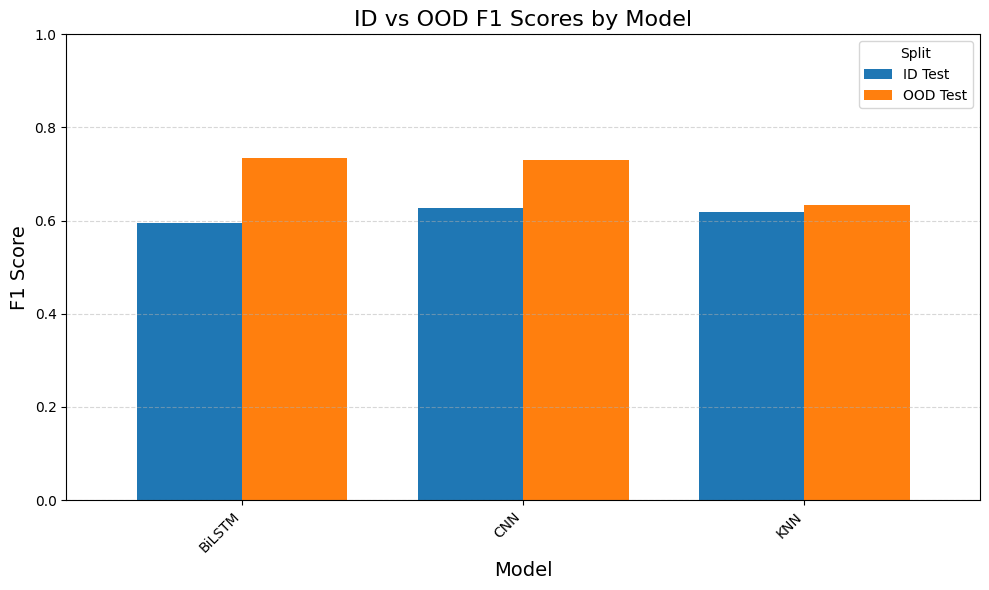

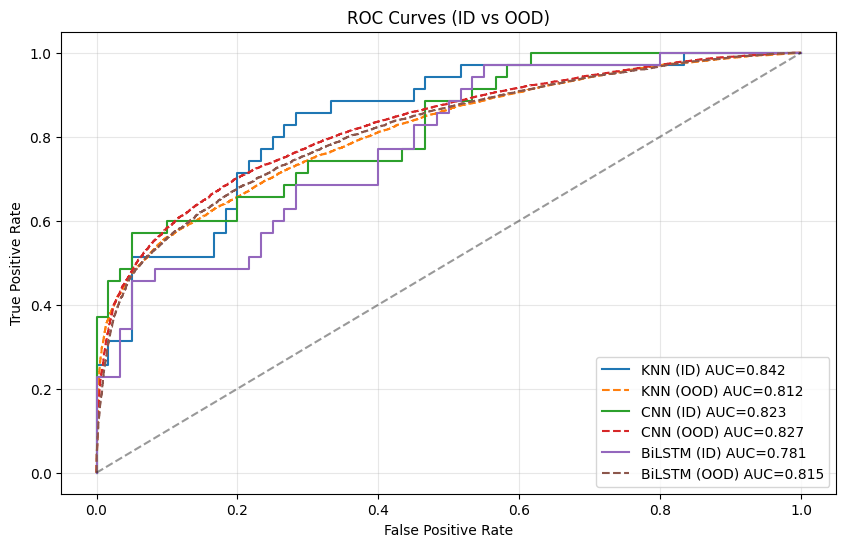

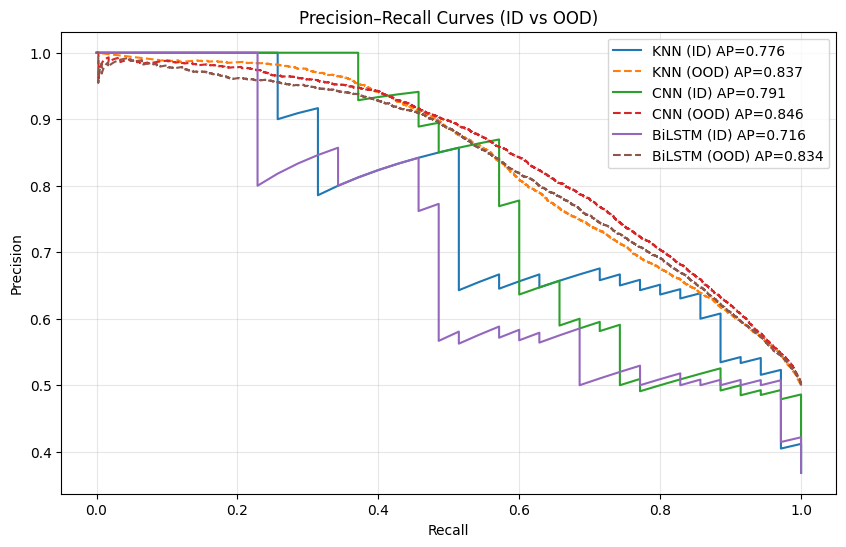

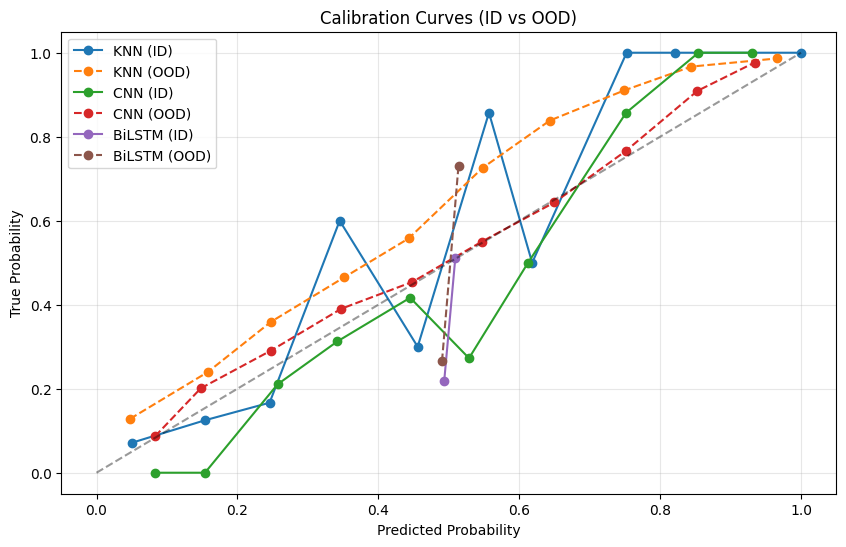

In [ ]:
# Ablation Plotting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

results = []

def get_predictions(model, loader, is_knn=False):
    if is_knn:
        seqs = []
        ys = []
        for xb, yb in loader:
            xb_np = xb.permute(0,2,1).numpy()
            for row in xb_np:
                seq = "".join("ACGT"[i] for i in row.argmax(axis=1))
                seqs.append(seq)
            ys.append(yb.numpy())

        ys = np.hstack(ys)
        X = kmer_features(seqs)
        X = scaler.transform(X)
        prob = model.predict_proba(X)[:, 1]
        pred = (prob >= 0.5).astype(int)
        return ys, pred, prob

    else:
        return predict_nn(model, loader)

def evaluate_model(name, model, loaders, is_knn=False):
    y, p, pr = get_predictions(model, loaders['id_test'], is_knn=is_knn)
    record(name, "ID Test", y, p, pr)

    y, p, pr = get_predictions(model, loaders['ood_test'], is_knn=is_knn)
    record(name, "OOD Test", y, p, pr)

evaluate_model("KNN", knn, loaders, is_knn=True)
evaluate_model("CNN", cnn, loaders, is_knn=False)
evaluate_model("BiLSTM", bilstm, loaders, is_knn=False)

df = pd.DataFrame(results)
df_f1 = df[df['Split'].isin(['ID Test', 'OOD Test'])]
pivot = df_f1.pivot(index='Model', columns='Split', values='f1')
pivot = pivot.loc[sorted(pivot.index)]

plt.figure(figsize=(10,6))
pivot.plot(kind='bar', figsize=(10,6), width=0.75)
plt.title("ID vs OOD F1 Scores by Model", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

def plot_roc_curves(models, loaders):
    plt.figure(figsize=(10, 6))

    for name, model in models.items():
        is_knn = ("KNN" in name)
        for split_key, split_label, style in [('id_test', 'ID', '-'), ('ood_test', 'OOD', '--')]:
            y, _, pr = get_predictions(model, loaders[split_key], is_knn=is_knn)
            fpr, tpr, _ = roc_curve(y, pr)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, linestyle=style, label=f"{name} ({split_label}) AUC={roc_auc:.3f}")

    plt.plot([0,1],[0,1],'k--',alpha=0.4)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (ID vs OOD)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_curves(
    {"KNN": knn, "CNN": cnn, "BiLSTM": bilstm}, loaders)

def plot_pr_curves(models, loaders):
    plt.figure(figsize=(10, 6))

    for name, model in models.items():
        is_knn = ("KNN" in name)
        for split_key, split_label, style in [('id_test', 'ID', '-'), ('ood_test', 'OOD', '--')]:
            y, _, pr = get_predictions(model, loaders[split_key], is_knn=is_knn)
            precision, recall, _ = precision_recall_curve(y, pr)
            ap = average_precision_score(y, pr)
            plt.plot(recall, precision, linestyle=style,
                     label=f"{name} ({split_label}) AP={ap:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curves (ID vs OOD)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_pr_curves(
    {"KNN": knn, "CNN": cnn, "BiLSTM": bilstm}, loaders)

def plot_calibration(models, loaders):
    plt.figure(figsize=(10, 6))

    for name, model in models.items():
        is_knn = ("KNN" in name)
        for split_key, split_label, style in [('id_test', 'ID', '-'), ('ood_test', 'OOD', '--')]:
            y, _, pr = get_predictions(model, loaders[split_key], is_knn=is_knn)
            prob_true, prob_pred = calibration_curve(y, pr, n_bins=10)
            plt.plot(prob_pred, prob_true, linestyle=style, marker='o',
                     label=f"{name} ({split_label})")

    plt.plot([0,1],[0,1],'k--',alpha=0.4)
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.title("Calibration Curves (ID vs OOD)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_calibration({"KNN": knn,"CNN": cnn, "BiLSTM": bilstm},loaders)
